
<h1 id="DSSD-front-back-Correlation(II)---dssd1">DSSD front-back Correlation(II) - dssd1</h1><h2 id="Supplementary-Multi-path-Formulation-of-Strip-Normalization">Supplementary Multi-path Formulation of Strip Normalization</h2><p>As in the main Tutorial 3.5, we adopt one front strip $X_r$ as the baseline reference and define its raw amplitude as the detector-internal relative energy scale:</p>
<p>$$
E^{(\mathrm{rel})} \equiv A_{x,r},
\qquad
k_{x,r}=1,
\qquad
b_{x,r}=0,
\qquad
\sigma(k_{x,r})=0,
\qquad
\sigma(b_{x,r})=0.
$$</p>
<p>The task remains the same as in the main tutorial: determine the strip-wise global parameters</p>
<p>$$
E_{x,i}^{(\mathrm{rel})}=k_{x,i}A_{x,i}+b_{x,i},
\qquad
E_{y,j}^{(\mathrm{rel})}=k_{y,j}A_{y,j}+b_{y,j},
$$</p>
<p>so that both detector sides are mapped onto one unified relative scale.</p>
<p>The difference in the present note is purely <strong>algorithmic</strong>. Instead of organizing the calibration only as a fixed three-step strip sequence, we describe the same problem as a <strong>multi-path propagation process</strong> on the strip-pixel network. This makes the generation of candidate parameters, the propagation of uncertainties, and the fusion of multiple calibration paths explicit.</p>
<hr/>
<h3 id="The-Local-Pixel-Bridges">The Local Pixel Bridges</h3><p>In the main Tutorial 3.5, the relative scale is propagated strip by strip through selected high-statistics regions. In the present supplementary formulation, the same propagation is expressed in terms of <strong>local pixel bridges</strong>.</p>
<p>For a purified single-pixel event at $(i,j)$, a local linear fit gives:</p>
<p>$$
A_{x,i}=s_{ij}A_{y,j}+t_{ij}.
$$</p>
<p>This local relation is the elementary bridge connecting the front strip $X_i$ and the back strip $Y_j$. Once a source strip already has known global parameters, the local bridge can be used to generate a <strong>path-specific candidate</strong> for the strip on the opposite side.</p>
<p>To describe this clearly, we distinguish between:</p>
<ul>
<li>The <strong>current global state</strong> of an already calibrated source strip.</li>
<li>The <strong>path-specific candidate</strong> generated for a target strip through one particular pixel bridge.</li>
</ul>
<h4 id="Forward-propagation-$(X-%5Crightarrow-Y)$">Forward propagation $(X \rightarrow Y)$</h4><p>Using the current global parameters of $X_i$, we generate a candidate for $Y_j$:
$$
k^{[i]}_{y,j}=k_{x,i}s_{ij},
\qquad
b^{[i]}_{y,j}=k_{x,i}t_{ij}+b_{x,i}.
$$</p>
<h4 id="Reverse-propagation-$(Y-%5Crightarrow-X)$">Reverse propagation $(Y \rightarrow X)$</h4><p>Using the current global parameters of $Y_j$, we generate a candidate for $X_i$:
$$
k^{[j]}_{x,i}=\frac{k_{y,j}}{s_{ij}},
\qquad
b^{[j]}_{x,i}=b_{y,j}-\frac{k_{y,j}t_{ij}}{s_{ij}}.
$$</p>
<p>In this way, each purified pixel provides a local bridge, and the detector-wide relative scale can be propagated from already calibrated strips to new ones.</p>
<h3 id="Path-wise-Propagation">Path-wise Propagation</h3><p>The propagation idea is the same as in the main Tutorial 3.5: start from a reliable reference strip and extend the relative scale step by step until the detector is covered.</p>
<p>Suppose $X_r$ is the baseline reference strip. Since its global parameters are already fixed, the local fit of pixel $(r,j_1)$ can be used together with the forward-propagation formula to generate the calibration parameters of the back strip $Y_{j_1}$. Once $Y_{j_1}$ becomes calibrated, the local bridge at another pixel $(i_1,j_1)$ can be used in the reverse direction to generate the parameters of the front strip $X_{i_1}$. The newly calibrated strip $X_{i_1}$ can then continue to propagate the scale to additional back strips.</p>
<p>Therefore, the detector-wide calibration can be viewed as a propagation process on the strip-pixel network: already calibrated strips serve as sources, local pixel fits serve as bridges, and newly generated strip parameters serve as the next wave of sources. This is the same physical task as the strip-normalization sequence in the main tutorial, now written in a form that is more convenient for algorithmic extension.</p>
<p><img alt="" src="fig/dssd_calibration.png" width="400"/></p>
<h3 id="Explicit-Uncertainty-Propagation">Explicit Uncertainty Propagation</h3><p>The local pixel fits inherently contain uncertainties $\sigma(s_{ij})$ and $\sigma(t_{ij})$. According to the law of error propagation, the variances of these <strong>candidate parameters</strong> depend on both the local fit errors and the <em>current global uncertainties</em> of the source strip:</p>
<p><strong>Variances for the candidate parameters of $Y_j$ (from source $X_i$):</strong>
$$\sigma^2\!\left(k_{y,j}^{[i]}\right) \approx s_{ij}^2\,\sigma^2(k_{x,i}) + k_{x,i}^2\,\sigma^2(s_{ij})$$
$$\sigma^2\!\left(b_{y,j}^{[i]}\right) \approx t_{ij}^2\,\sigma^2(k_{x,i}) + k_{x,i}^2\,\sigma^2(t_{ij}) + \sigma^2(b_{x,i})$$</p>
<p><strong>Variances for the candidate parameters of $X_i$ (from source $Y_j$):</strong>
$$\sigma^2\!\left(k_{x,i}^{[j]}\right) \approx \frac{\sigma^2(k_{y,j})}{s_{ij}^2} + \frac{k_{y,j}^2}{s_{ij}^4}\sigma^2(s_{ij})$$
$$\sigma^2\!\left(b_{x,i}^{[j]}\right) \approx \sigma^2(b_{y,j}) + \left(\frac{t_{ij}}{s_{ij}}\right)^2\!\sigma^2(k_{y,j}) + \left(\frac{k_{y,j}}{s_{ij}}\right)^2\!\sigma^2(t_{ij}) + \left(\frac{k_{y,j}t_{ij}}{s_{ij}^2}\right)^2\!\sigma^2(s_{ij})$$</p>
<p><em>(Note: The variables like $k_{x,i}$ and $\sigma^2(k_{x,i})$ on the right side of the equations simply refer to the global values obtained from the previous iterative process).</em></p>
<hr/>
<h3 id="Multi-path-Fusion-by-Inverse-Variance-Weighting">Multi-path Fusion by Inverse-Variance Weighting</h3><p>The main Tutorial 3.5 uses a practical strip-normalization sequence to propagate the relative scale across DSSD1. The present supplementary formulation makes clear that, in the full strip-pixel network, this propagation is generally <strong>multi-path</strong> rather than strictly one-dimensional.</p>
<p>A single target strip may intersect several already calibrated strips on the opposite side. As a result, it may receive multiple path-specific candidates for its global parameters at the same time. These candidates are not identical, because they come from different local bridges and different source-strip uncertainties.</p>
<p>To combine them consistently, we use <strong>inverse-variance weighting</strong>: candidates with smaller propagated uncertainty receive larger weights.</p>
<p>For a back strip $Y_j$, let $\mathcal{C}_j$ be the set of all already calibrated front strips that can provide candidates to it. Then:
$$
w^{(k)}_{ij}=\frac{1}{\sigma^2\!\left(k^{[i]}_{y,j}\right)},
\qquad
w^{(b)}_{ij}=\frac{1}{\sigma^2\!\left(b^{[i]}_{y,j}\right)}.
$$</p>
<p>The fused global parameters are:
$$
k_{y,j} = \frac{\sum_{i\in\mathcal{C}_j} w^{(k)}_{ij}k^{[i]}_{y,j}}{\sum_{i\in\mathcal{C}_j} w^{(k)}_{ij}},
\qquad
\sigma^2(k_{y,j}) = \frac{1}{\sum_{i\in\mathcal{C}_j} w^{(k)}_{ij}},
$$
$$
b_{y,j} = \frac{\sum_{i\in\mathcal{C}_j} w^{(b)}_{ij}b^{[i]}_{y,j}}{\sum_{i\in\mathcal{C}_j} w^{(b)}_{ij}},
\qquad
\sigma^2(b_{y,j}) = \frac{1}{\sum_{i\in\mathcal{C}_j} w^{(b)}_{ij}}.
$$</p>
<p>Similarly, for a front strip $X_i$, let $\mathcal{C}_i$ be the set of all already calibrated back strips that can provide candidates, and the fused parameters are updated in the same way. The detector-wide calibration is obtained by iterating the loop:
$$
\text{current global state} \rightarrow \text{path-wise candidates} \rightarrow \text{inverse-variance fusion} \rightarrow \text{updated global state}
$$
until the strip parameters become stable. This provides a more explicit algorithmic generalization of the strip-normalization idea introduced in the main Tutorial 3.5.</p>
<h3>Covariance 与独立性</h3><p>上面的逐项平方和仅适用于忽略相关项的近似。令输入参数向量为 u，传播后的参数为 v(u)，一般公式为 \(C_v=J C_u J^T\)，其中 \(J_{ij}=\partial v_i/\partial u_j\)。同一次直线拟合的 slope 与 intercept 通常相关，不能遗漏它们的 covariance。</p><p>下面的小例子固定 X15 为相对单位的定义，三条路径使用互不重叠的 pixel 事例，并近似忽略探测器共同系统误差。代码保留每条路径内部 k、b 的 covariance。分别对 k、b 作 inverse-variance 平均只是便于演示的组合，不是一般情况下的最优联合估计。若循环使用同一 pixel 或共享一个有误差的参考，不能反复当作独立新信息迭代，否则会低估误差。</p>

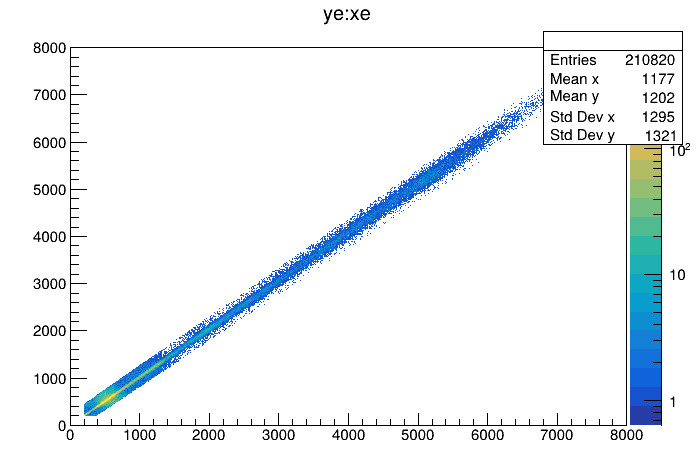

In [2]:
TCanvas *c1 = new TCanvas("c1","c1");
TFile *fin = new TFile("./data/d1xy.root");
TTree *tree =(TTree *)fin->Get("tree");
tree->Draw("ye:xe>>(1000,0,8000,1000,0,8000)","","colz");
c1->SetLogz();
c1->Draw();


<h3 id="Worked-Demo-of-Multi-path-Propagation">Worked Demo of Multi-path Propagation</h3><p>Using the same purified single-pixel event sample <code>d1xy.root</code> as in the main Tutorial 3.5, we can build a compact demonstration of the multi-path formulation.</p>
<p>This demo is <strong>not intended to replace</strong> the practical strip-normalization route presented in the main tutorial. Instead, it serves as a small worked example showing how the relative scale can be propagated through local pixel bridges, how multiple path-wise candidates arise, and how they are fused by inverse-variance weighting.</p>
<p>The example considered here is:
$$
X_{15} \;\xrightarrow{\text{forward}}\; \{Y_7,\,Y_{12},\,Y_{20}\} \;\xrightarrow{\text{reverse}}\; X_5 \;\xrightarrow{\text{fusion}}\; \text{final }(k_{x,5},\,b_{x,5}).
$$</p>
<p>This example illustrates the essential logic of the supplementary algorithm:</p>
<ul>
<li>Start from a calibrated reference strip.</li>
<li>Propagate the relative scale to several strips on the opposite side.</li>
<li>Generate multiple candidates for a new target strip.</li>
<li>Fuse these candidates according to their propagated uncertainties.</li>
<li>Compare the raw and calibrated correlations visually.</li>
</ul>
<h3 id="Implementation">Implementation</h3><p>The implementation below follows the supplementary multi-path formulation introduced above. For clarity, the code is organized into several functional blocks: data structures, propagation engine, fusion engine, local fitting helper, and visualization.</p>
<p>This organization is intended to make the algorithmic structure transparent for students who wish to study the calibration process in greater detail, especially the handling of path-wise candidates and propagated uncertainties.</p>
<p>先用 ROB 给初始直线，再用 residual 的稳健尺度选择主体条带。最终 LS 的误差是在这个选择和模型之下的条件误差；它未包含 cut 变化或误认组合带来的系统误差。</p>

In [ ]:
#include <iostream>
#include <vector>
#include <cmath>
#include "TFile.h"
#include "TTree.h"
#include "TGraph.h"
#include "TF1.h"
#include "TH2F.h"
#include "TCanvas.h"
#include "TStyle.h"

using namespace std;

In [ ]:
// ============================================
// Block 1: Data Structures
// ============================================

// Current Global Parameters for a strip
struct StripParam {
    double k = 1.0, b = 0.0;
    double vk = 1e9, vb = 1e9;  // Variance (large = uncalibrated)
    bool isCalibrated = false;
    double ckb = 0; // Cov(k,b)
};

// Local Pixel Bridge from fit
struct PixelFit {
    double s = 0, t = 0;
    double vs = 0, vt = 0;
    bool isValid = false;
    double cst = 0; // Cov(s,t)
};

// Global arrays
StripParam calX[32], calY[32];

In [ ]:
// ============================================
// Block 2: Propagation Engine
// ============================================

// Forward: X -> Y (Eq.4 + Error Propagation)
StripParam ForwardPropagate(const StripParam& X, const PixelFit& p) {
    StripParam Y;
    Y.k  = X.k * p.s;
    Y.b  = X.k * p.t + X.b;
    Y.vk = p.s*p.s * X.vk + X.k*X.k * p.vs;
    Y.vb = p.t*p.t * X.vk + X.k*X.k * p.vt + X.vb + 2*p.t*X.ckb;
    Y.ckb = p.s*p.t*X.vk + p.s*X.ckb + X.k*X.k*p.cst;
    Y.isCalibrated = true;
    return Y;
}

In [ ]:
// Reverse: Y -> X (Eq.5 + Error Propagation)
StripParam ReversePropagate(const StripParam& Y, const PixelFit& p) {
    StripParam X;
    if (p.s == 0) return X;
    
    double s2 = p.s * p.s;
    double s4 = s2 * s2;
    
    X.k  = Y.k / p.s;
    X.b  = Y.b - Y.k * p.t / p.s;
    X.vk = Y.vk / s2 + Y.k*Y.k / s4 * p.vs;
    X.vb = Y.vb + pow(p.t/p.s, 2) * Y.vk 
               + pow(Y.k/p.s, 2) * p.vt 
               + pow(Y.k*p.t/s2, 2) * p.vs
               - 2*p.t/p.s*Y.ckb - 2*Y.k*Y.k*p.t/(s2*p.s)*p.cst;
    X.ckb = Y.ckb/p.s - p.t/s2*Y.vk
          + Y.k*Y.k/(s2*p.s)*p.cst - Y.k*Y.k*p.t/s4*p.vs;
    X.isCalibrated = true;
    return X;
}

In [ ]:
// ============================================
// Block 3: Fusion Engine (Inverse-Variance Weighting)
// ============================================

StripParam FuseCandidates(const vector<StripParam>& cands) {
    double swk = 0, swkk = 0;
    double swb = 0, swbb = 0;

    for (const auto& c : cands) {
        if (!c.isCalibrated || c.vk<=0 || c.vb<=0) continue;
        double wk = 1.0 / c.vk;
        double wb = 1.0 / c.vb;
        swkk += wk * c.k;  swk += wk;
        swbb += wb * c.b;  swb += wb;
    }

    StripParam result;
    if (swk<=0 || swb<=0) return result;
    result.k  = swkk / swk;
    result.b  = swbb / swb;
    result.vk = 1.0 / swk;
    result.vb = 1.0 / swb;
    for (const auto& c : cands) {
        if (c.isCalibrated && c.vk>0 && c.vb>0)
            result.ckb += c.ckb / (c.vk*c.vb*swk*swb);
    }
    result.isCalibrated = true;
    return result;
}

In [ ]:
PixelFit GetPixelRelation(TTree* tree, int xId, int yId, double nSigma = 3.0) {
    PixelFit fit;
    TString cut = Form("ix==%d && iy==%d", xId, yId);
    if (tree->GetEntries(cut) < 50) return fit;

    tree->SetEstimate(tree->GetEntries()+1);
    tree->Draw("xe:ye", cut, "goff");
    int n = tree->GetSelectedRows();
    vector<double> x(tree->GetV2(), tree->GetV2() + n);
    vector<double> y(tree->GetV1(), tree->GetV1() + n);

    // Stage 1: ROB fit for initial estimate
    TGraph gAll(n, &x[0], &y[0]);
    gAll.Fit("pol1", "ROB Q 0");
    double s0 = gAll.GetFunction("pol1")->GetParameter(1);
    double t0 = gAll.GetFunction("pol1")->GetParameter(0);

    // Stage 2: MAD-based outlier rejection
    vector<double> absRes;
    for (int i = 0; i < n; i++) 
        absRes.push_back(fabs(y[i] - s0 * x[i] - t0));
    vector<double> sortedRes = absRes; // 只排序副本，保留事例对应
    sort(sortedRes.begin(), sortedRes.end());
    double sigma = 1.4826 * sortedRes[n / 2];
    if (sigma <= 0) return fit;

    // Stage 3: Refit cleaned data with standard LS
    TGraph gClean;
    for (int i = 0; i < n; i++)
        if (absRes[i] < nSigma * sigma) 
            gClean.SetPoint(gClean.GetN(), x[i], y[i]);

    if (gClean.GetN() < 3) return fit;
    TFitResultPtr r = gClean.Fit("pol1", "Q S 0");
    if (r.Get() && r->IsValid()) {
        fit = {r->Parameter(1), r->Parameter(0), 
               pow(r->ParError(1), 2), pow(r->ParError(0), 2), true};
        fit.cst = r->CovMatrix(1,0);
        printf("  Pixel(%2d,%2d): s=%.4f±%.4f, t=%5.1f±%.1f [N=%d, cut=%d]\n",
               xId, yId, fit.s, sqrt(fit.vs), fit.t, sqrt(fit.vt), 
               gClean.GetN(), n - gClean.GetN());
    }
    return fit;
}

In [ ]:
// ============================================
// Block 5: Visualization
// ============================================

void DrawValidation(TTree* tree, 
                    const vector<pair<int,int>>& pixels,
                    const char* title = "Validation") {
    TH2F* hRaw = new TH2F("hRaw", "Raw ADC;X (ADC);Y (ADC)", 
                          1000, 0, 8000, 1000, 0, 8000);
    TH2F* hCal = new TH2F("hCal", "Calibrated;X (Rel.Energy);Y (Rel.Energy)", 
                          1000, 0, 8000, 1000, 0, 8000);
    // 保留前面阶段的 canvas。


    Int_t ix, iy, xe, ye;
    tree->SetBranchAddress("ix", &ix);
    tree->SetBranchAddress("iy", &iy);
    tree->SetBranchAddress("xe", &xe);
    tree->SetBranchAddress("ye", &ye);

    for (Long64_t i = 0; i < tree->GetEntries(); i++) {
        tree->GetEntry(i);
        for (const auto& pix : pixels) {
            if (ix == pix.first && iy == pix.second) {
                hRaw->Fill(xe, ye);
                if (calX[ix].isCalibrated && calY[iy].isCalibrated) {
                    double eX = calX[ix].k * xe + calX[ix].b;
                    double eY = calY[iy].k * ye + calY[iy].b;
                    hCal->Fill(eX, eY);
                }
            }
        }
    }

    gStyle->SetOptStat(0);
    TCanvas* c = new TCanvas("cVal", title, 1000, 450);
    c->Divide(2, 1);
    c->cd(1); hRaw->Draw("colz");
    c->cd(2); hCal->Draw("colz");
    c->Draw();
    tree->ResetBranchAddresses(); // 局部变量即将离开作用域
}

In [ ]:
// ============================================
// Main Demo: Multi-path Propagation Example
// ============================================

void MultiPathDemo() {
    TFile* fin = TFile::Open("./data/d1xy.root");
    if (!fin || fin->IsZombie()) { 
        cout << "Error: File missing!" << endl; 
        return; 
    }
    TTree* tree = (TTree*)fin->Get("tree");

    // Initialize: X15 as absolute baseline
    int refX = 15;
    calX[refX] = {1.0, 0.0, 0.0, 0.0, true};

    // Step 1: Forward Propagation (X15 -> Y7, Y12, Y20)
    cout << "=== Step 1: Forward X[15] -> Y[7,12,20] ===" << endl;
    vector<int> targetY = {7, 12, 20};
    
    for (int y : targetY) {
        PixelFit pf = GetPixelRelation(tree, refX, y);
        if (pf.isValid) {
            calY[y] = ForwardPropagate(calX[refX], pf);
            printf("  -> Y[%2d]: k = %.4f ± %.4f, b = %6.1f ± %.1f\n",
                   y, calY[y].k, sqrt(calY[y].vk), calY[y].b, sqrt(calY[y].vb));
        }
    }

    // Step 2: Reverse Propagation (Y7, Y12, Y20 -> X5)
    cout << "\n=== Step 2: Reverse Y[7,12,20] -> X[5] ===" << endl;
    int targetX = 5;
    vector<StripParam> candidates;

    for (int y : targetY) {
        PixelFit pf = GetPixelRelation(tree, targetX, y);
        if (pf.isValid && calY[y].isCalibrated) {
            StripParam cand = ReversePropagate(calY[y], pf);
            candidates.push_back(cand);
            printf("  -> Candidate from Y[%2d]: k = %.4f ± %.4f, b = %6.1f ± %.1f\n",
                   y, cand.k, sqrt(cand.vk), cand.b, sqrt(cand.vb));
        }
    }

    // Step 3: Inverse-Variance Weighted Fusion
    cout << "\n=== Step 3: Fusion ===" << endl;
    calX[targetX] = FuseCandidates(candidates);
    printf(">>> X[5] Final: k = %.4f ± %.4f, b = %6.1f ± %.1f <<<\n",
           calX[targetX].k, sqrt(calX[targetX].vk), 
           calX[targetX].b, sqrt(calX[targetX].vb));

    // Step 4: Visualization
    cout << "\n=== Step 4: Drawing Validation ===" << endl;
    vector<pair<int,int>> pixels = {{15,7}, {15,12}, {15,20}, {5,7}, {5,12}, {5,20}};
    DrawValidation(tree, pixels, "Multi-path Propagation Validation");
}

=== Step 1: Forward X[15] -> Y[7,12,20] ===
  Pixel(15, 7): s=0.9892±0.0001, t= 11.0±0.3 [N=284, cut=121]
  -> Y[ 7]: k = 0.9892 ± 0.0001, b =   11.0 ± 0.3
  Pixel(15,12): s=0.9971±0.0001, t=  4.9±0.4 [N=333, cut=162]
  -> Y[12]: k = 0.9971 ± 0.0001, b =    4.9 ± 0.4
  Pixel(15,20): s=0.9797±0.0001, t=-17.9±0.3 [N=224, cut=111]
  -> Y[20]: k = 0.9797 ± 0.0001, b =  -17.9 ± 0.3

=== Step 2: Reverse Y[7,12,20] -> X[5] ===
  Pixel( 5, 7): s=0.9736±0.0003, t= 13.4±0.3 [N=145, cut=71]
  -> Candidate from Y[ 7]: k = 1.0160 ± 0.0003, b =   -2.6 ± 0.4
  Pixel( 5,12): s=0.9814±0.0003, t=  7.8±0.3 [N=138, cut=62]
  -> Candidate from Y[12]: k = 1.0160 ± 0.0003, b =   -3.1 ± 0.5
  Pixel( 5,20): s=0.9632±0.0002, t=-13.9±0.3 [N=126, cut=62]
  -> Candidate from Y[20]: k = 1.0172 ± 0.0003, b =   -3.7 ± 0.4

=== Step 3: Fusion ===
>>> X[5] Final: k = 1.0164 ± 0.0002, b =   -3.2 ± 0.2 <<<

=== Step 4: Drawing Validation ===

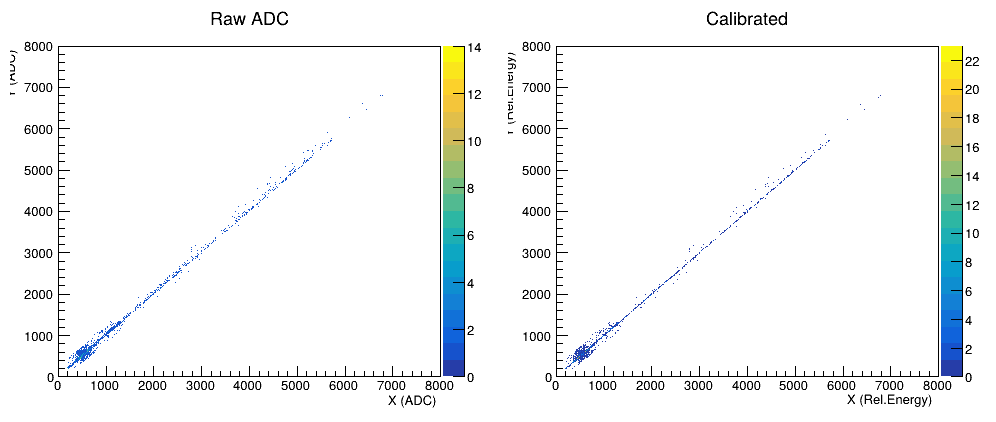

In [12]:
MultiPathDemo()